In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

iris = datasets.load_iris()
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [2]:
X = iris["data"][:,3:] # select only the 4-th feature: petal width
y = (iris["target"]==2).astype(int) # 1 if Iris virginica, else 0

In [3]:
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

# Let's look at the model's estimated probabilities for flowers with petal widths ranging from 0 to 3 cm:

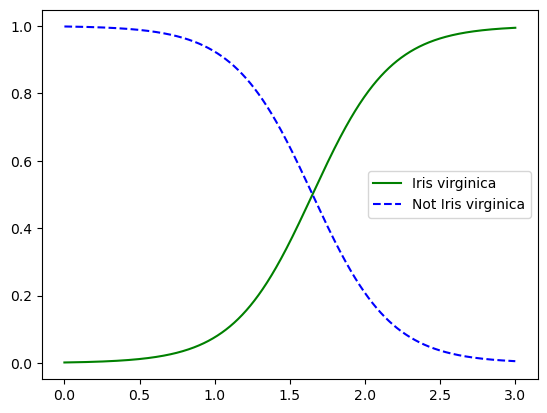

In [4]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)  # reshape to get a column vector
y_proba = log_reg.predict_proba(X_new)
plt.plot(X_new, y_proba[:,-1],"g-",label="Iris virginica")
plt.plot(X_new, y_proba[:,0],"b--",label="Not Iris virginica")
plt.legend(loc='best')
plt.show()

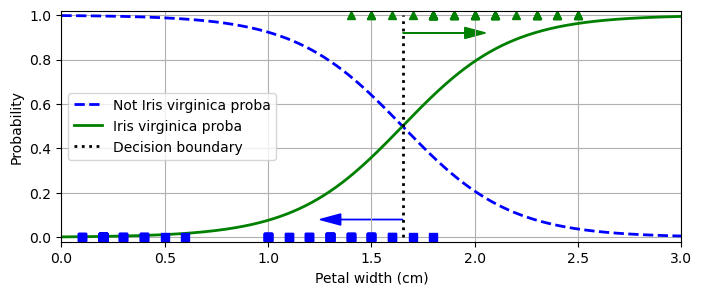

In [5]:
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.figure(figsize=(8, 3))  # extra code – not needed, just formatting
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2,
         label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2,
         label="Decision boundary")

# extra code – this section beautifies and saves Figure 4–23
plt.arrow(x=decision_boundary, y=0.08, dx=-0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="b", ec="b")
plt.arrow(x=decision_boundary, y=0.92, dx=0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="g", ec="g")
plt.plot(X_train[y_train == 0], y_train[y_train == 0], "bs")
plt.plot(X_train[y_train == 1], y_train[y_train == 1], "g^")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend(loc="center left")
plt.axis([0, 3, -0.02, 1.02])
plt.grid()
plt.show()

a decision boundary is at aroung 1.6 cm

In [6]:
decision_boundary

1.6516516516516517

In [7]:
log_reg.predict([[1.7],[1.5]])

array([1, 0])

# Let's include petal length as well: two features input (petal length, petal width)

In [8]:
X2 = iris["data"][:,(2,3)]
X_train, X_test, y_train, y_test = train_test_split(X2, y, random_state=42)

log_reg2 = LogisticRegression(C=2, random_state=42)
log_reg2.fit(X_train, y_train)

LogisticRegression(C=2, random_state=42)

In [9]:
# for the contour plot
x0, x1 = np.meshgrid(np.linspace(2.9, 7, 500).reshape(-1, 1),
                     np.linspace(0.8, 2.7, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]  # one instance per point on the figure
y_proba = log_reg2.predict_proba(X_new)
zz = y_proba[:, 1].reshape(x0.shape)

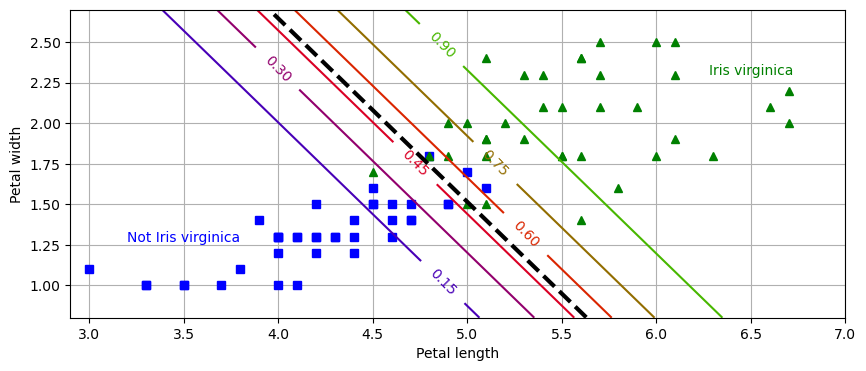

In [10]:
# for the decision boundary
left_right = np.array([2.9, 7])
boundary = -((log_reg2.coef_[0, 0] * left_right + log_reg2.intercept_[0])
             / log_reg2.coef_[0, 1])

plt.figure(figsize=(10, 4))
plt.plot(X_train[y_train == 0, 0], X_train[y_train == 0, 1], "bs")
plt.plot(X_train[y_train == 1, 0], X_train[y_train == 1, 1], "g^")
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg)
plt.clabel(contour, inline=1)
plt.plot(left_right, boundary, "k--", linewidth=3)
plt.text(3.5, 1.27, "Not Iris virginica", color="b", ha="center")
plt.text(6.5, 2.3, "Iris virginica", color="g", ha="center")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.axis([2.9, 7, 0.8, 2.7])
plt.grid()
plt.show()

# to multi-class : Softmax Regression

In [ ]:
X3 = iris["data"][:,2:] # take into account the last two features
y3 = iris["target"] # 3 classes: 0, 1 and 2

X_train, X_test, y_train, y_test = train_test_split(X3, y3, random_state=42)

softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train, y_train)

LogisticRegression(C=30, random_state=42)

In [12]:
softmax_reg.predict([[5, 2]])

array([2])

In [13]:
softmax_reg.predict_proba([[5, 2]])


array([[3.37167169e-08, 4.06723544e-02, 9.59327612e-01]])

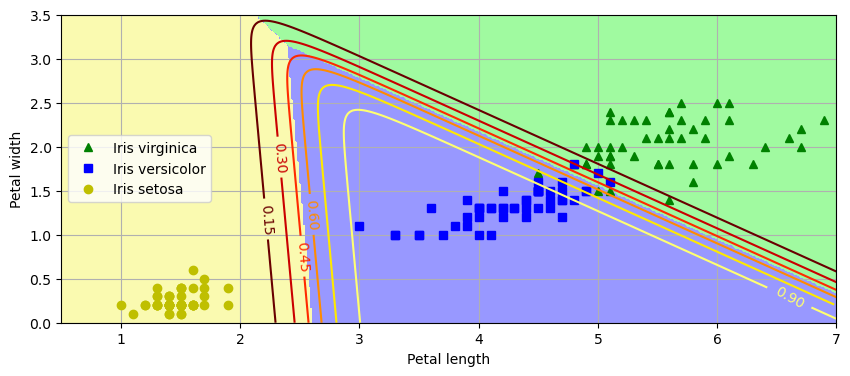

In [14]:
# extra code – this cell generates and saves Figure 4–25

from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])

x0, x1 = np.meshgrid(np.linspace(0, 8, 500).reshape(-1, 1),
                     np.linspace(0, 3.5, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]

y_proba = softmax_reg.predict_proba(X_new)
y_predict = softmax_reg.predict(X_new)

zz1 = y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X3[y3 == 2, 0], X3[y3 == 2, 1], "g^", label="Iris virginica")
plt.plot(X3[y3 == 1, 0], X3[y3 == 1, 1], "bs", label="Iris versicolor")
plt.plot(X3[y3 == 0, 0], X3[y3 == 0, 1], "yo", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="center left")
plt.axis([0.5, 7, 0, 3.5])
plt.grid()
plt.show()